# **IMPORT NECESSARY LIBRARIES**

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import scipy.sparse
from sklearn.model_selection import train_test_split, GridSearchCV
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# **LOAD DATASET**

In [2]:
 df = pd.read_csv('balanced_dataset_final.csv')

In [3]:
# Initial Data Cleaning
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

# Handle missing values in 'Review' column by converting them to empty strings
df['Review'] = df['Review'].fillna('')
y_rating_original = df['Rating'].astype(int) # Ensure target is integer

print("--- Data Initialized ---")
print(f"Total Records: {len(df)}")
print("\nFirst 5 rows:")
print(df.head())
print("\nClass distribution:")
print(y_rating_original.value_counts())

--- Data Initialized ---
Total Records: 15000

First 5 rows:
   Rating                                             Review  word_count
0       1                        worst model user please buy           5
1       1                       inferior quality looks cheap           4
2       1  bad product product stopped working switch hol...          10
3       1                                   wood part broken           3
4       1                        worst materials waste money           4

Class distribution:
Rating
1    3000
2    3000
3    3000
4    3000
5    3000
Name: count, dtype: int64


# **TRAIN TEST SPLIT**

In [4]:
# Define features (X) and target (y)
X_text = df['Review']
y = y_rating_original

# Stratified Split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    stratify=y, # Ensures the class proportion is maintained in both splits
    random_state=42
)

print("\n--- Train Test Split Completed ---")
print(f"Training set size: {len(X_train_text)}")
print(f"Test set size: {len(X_test_text)}")

# --- Text Vectorization (TF-IDF) ---
# Fit TfidfVectorizer only on the training data to prevent data leakage
tfidf = TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print(f"Feature matrix shape after TF-IDF: {X_train.shape}")


--- Train Test Split Completed ---
Training set size: 12000
Test set size: 3000
Feature matrix shape after TF-IDF: (12000, 10000)


# **DATA VISUALIZATION OF TRAINING**

/tmp/ipython-input-2901783861.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, order=sorted(y_train.unique()), palette='coolwarm')
/tmp/ipython-input-2901783861.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test, order=sorted(y_test.unique()), palette='coolwarm')


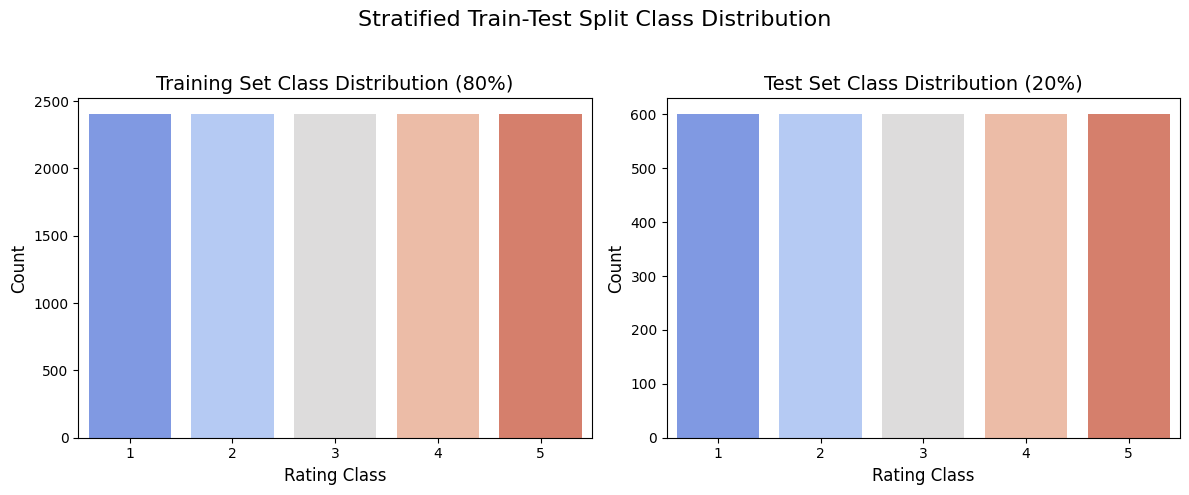

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train, order=sorted(y_train.unique()), palette='coolwarm')
plt.title('Training Set Class Distribution (80%)', fontsize=14)
plt.xlabel('Rating Class', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.subplot(1, 2, 2)
sns.countplot(x=y_test, order=sorted(y_test.unique()), palette='coolwarm')
plt.title('Test Set Class Distribution (20%)', fontsize=14)
plt.xlabel('Rating Class', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.suptitle('Stratified Train-Test Split Class Distribution', fontsize=16)
plt.tight_layout(rect=[0, 0.0, 1, 0.95]) # Adjust for suptitle
plt.show()

# **MODELLING**

In [12]:
models_to_train = {
    'Logistic Regression (Base)': LogisticRegression(random_state=42, solver='liblinear', multi_class='ovr', max_iter=1000),
    'SVM (Base)': SVC(random_state=42),
    'Naive Bayes (Base)': MultinomialNB(),
    'Random Forest (Base)': RandomForestClassifier(random_state=42, n_estimators=200, n_jobs=-1)
}

results = {}
best_accuracy = 0

print("\n" + "="*70)
print("Starting Model Training and Evaluation (Base Models)")
print("="*70)

for name, model in models_to_train.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    results[name] = {'accuracy': accuracy, 'model': model}

    print(f"\n--- {name} Accuracy: {accuracy:.4f} ---")


Starting Model Training and Evaluation (Base Models)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



--- Logistic Regression (Base) Accuracy: 0.4643 ---

--- Support Vector Machine (Base) Accuracy: 0.4680 ---

--- Multinomial Naive Bayes (Base) Accuracy: 0.4487 ---

--- Random Forest (Base) Accuracy: 0.4630 ---


# **FINE-TUNING**

In [19]:
print("\n" + "#"*70)
print("Starting Fine-Tuning (Grid Search) on all four models")
print("#"*70)

tuned_models_and_params = {
    'Logistic Regression': (LogisticRegression(solver='liblinear', multi_class='ovr', random_state=42, max_iter=1000),
                            {'C': [0.1, 1.0]}), # Restricted C grid
    'SVM': (SVC(random_state=42),
                               {'C': [0.1, 1.0], 'kernel': ['linear']}),
    'Naive Bayes': (MultinomialNB(),
                                {'alpha': [0.1, 0.5, 1.0]}), # Alpha tuning included
    'Random Forest': (RandomForestClassifier(random_state=42),
                      {'max_depth': [10, 20], 'n_estimators': [100]})
}

for name, (model, params) in tuned_models_and_params.items():
    print(f"\n--- Fine-Tuning {name} ---")

    grid_search = GridSearchCV(model, params, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)

    best_tuned_model = grid_search.best_estimator_

    # Evaluate the fine-tuned model
    y_pred_tuned = best_tuned_model.predict(X_test)
    accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
    results[name] = {'accuracy': accuracy_tuned, 'model': best_tuned_model}

    print(f"Best Hyperparameters: {grid_search.best_params_}")
    print(f"Accuracy (Tuned): {accuracy_tuned:.4f}")

# 5.3 Final check for the overall best model (including base and tuned)
final_best_accuracy = 0
final_best_model_name = None
final_best_model = None

for name, res in results.items():
    if res['accuracy'] > final_best_accuracy:
        final_best_accuracy = res['accuracy']
        final_best_model_name = name
        final_best_model = res['model']

print("\n" + "="*70)
print(f"OVERALL BEST MODEL IDENTIFIED: {final_best_model_name} with Accuracy: {final_best_accuracy:.4f}")
print("="*70)

# Print detailed report for the overall best model
y_pred_final = final_best_model.predict(X_test)
print(f"\nFINAL CLASSIFICATION REPORT for {final_best_model_name}:")
print(classification_report(y_test, y_pred_final))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))


######################################################################
Starting Fine-Tuning (Grid Search) on all four models
######################################################################

--- Fine-Tuning Logistic Regression ---
Fitting 3 folds for each of 2 candidates, totalling 6 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Best Hyperparameters: {'C': 0.1}
Accuracy (Tuned): 0.4703

--- Fine-Tuning SVM ---
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best Hyperparameters: {'C': 1.0, 'kernel': 'linear'}
Accuracy (Tuned): 0.4613

--- Fine-Tuning Naive Bayes ---
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best Hyperparameters: {'alpha': 1.0}
Accuracy (Tuned): 0.4487

--- Fine-Tuning Random Forest ---
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best Hyperparameters: {'max_depth': 20, 'n_estimators': 100}
Accuracy (Tuned): 0.4657

OVERALL BEST MODEL IDENTIFIED: Logistic Regression (Tuned) with Accuracy: 0.4703

FINAL CLASSIFICATION REPORT for Logistic Regression (Tuned):
              precision    recall  f1-score   support

           1       0.58      0.65      0.61       600
           2       0.41      0.42      0.42       600
           3       0.42      0.34      0.38       600
           4       0.39      0.38      0.38       600
           5       0.53      0.

# **DATA VISUALIZATION OF MODELLING**

/tmp/ipython-input-17248049.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sorted_names, y=sorted_accuracies, palette=colors)


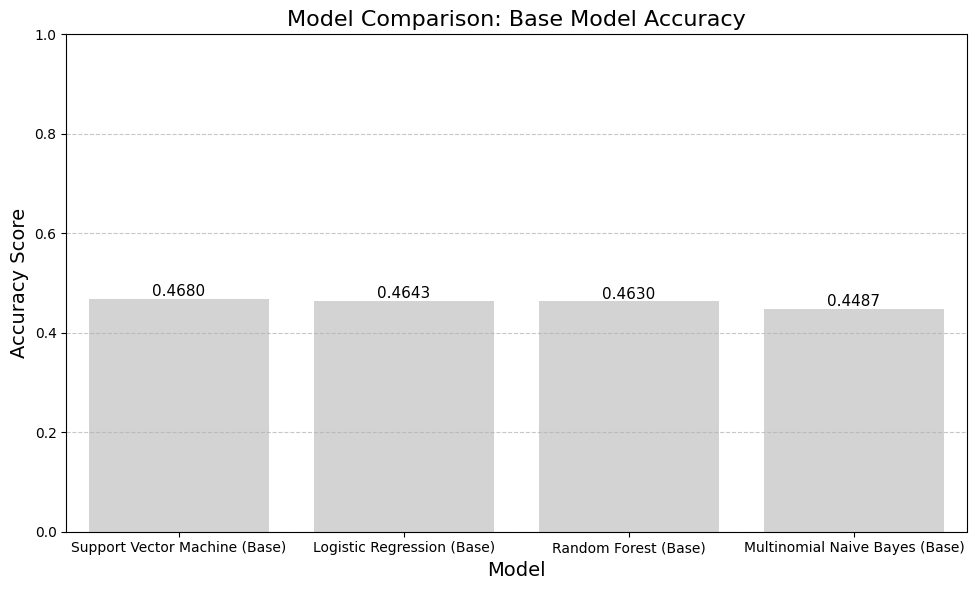

/tmp/ipython-input-17248049.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sorted_names, y=sorted_accuracies, palette=colors)


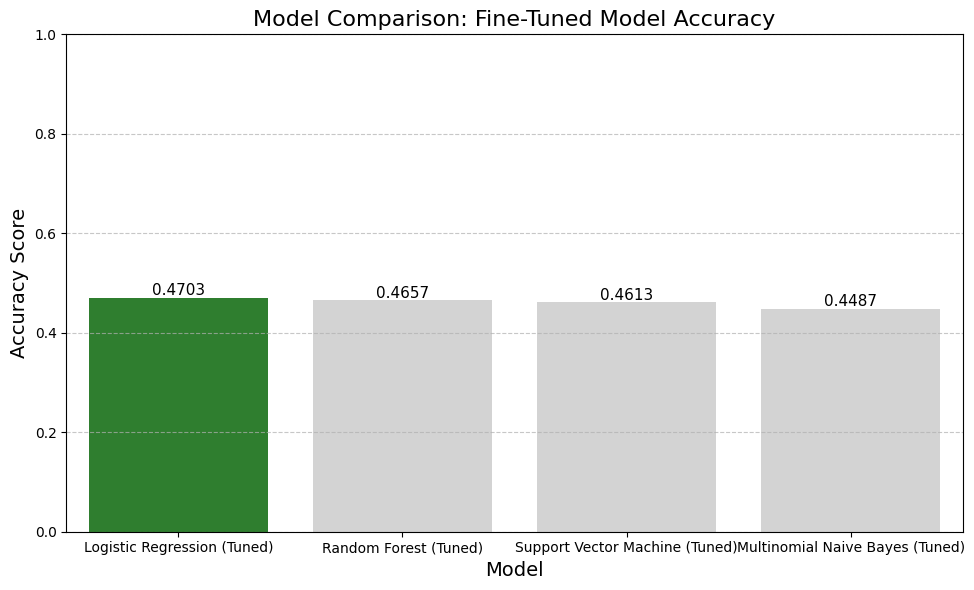

In [23]:
base_results = {k: v['accuracy'] for k, v in results.items() if '(Base)' in k}
tuned_results = {k: v['accuracy'] for k, v in results.items() if '(Tuned)' in k}


def plot_accuracy(data, title, overall_best_model_name):
    """Generates a sorted bar chart for model accuracies."""
    # Prepare data for plotting
    model_names = list(data.keys())
    accuracies = list(data.values())

    # Sort models by accuracy
    sorted_indices = np.argsort(accuracies)[::-1]
    sorted_names = [model_names[i] for i in sorted_indices]
    sorted_accuracies = [accuracies[i] for i in sorted_indices]

    plt.figure(figsize=(10, 6))

    # Define colors, highlighting the overall best model in green if present
    colors = ['lightgrey'] * len(sorted_names)
    if overall_best_model_name in sorted_names:
        best_index = sorted_names.index(overall_best_model_name)
        colors[best_index] = 'forestgreen'

    ax = sns.barplot(x=sorted_names, y=sorted_accuracies, palette=colors)

    # Add accuracy values on top of the bars
    for i, acc in enumerate(sorted_accuracies):
        ax.text(i, acc + 0.005, f'{acc:.4f}', ha='center', fontsize=11, color='black')

    plt.title(title, fontsize=16)
    plt.xlabel('Model', fontsize=14)
    plt.ylabel('Accuracy Score', fontsize=14)
    plt.ylim(0, 1.0)
    plt.xticks(ha='center', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Plot 1: Base Models
plot_accuracy(base_results, 'Model Comparison: Base Model Accuracy', final_best_model_name)

# Plot 2: Tuned Models
plot_accuracy(tuned_results, 'Model Comparison: Fine-Tuned Model Accuracy', final_best_model_name)

# **DOWNLOAD BEST MODEL & TEST SET**

In [28]:
# Define filenames
model_filename = 'Model_A.pkl'
vectorizer_filename = 'balanced_tfidf_vectorizer.pkl'
test_csv_filename = 'balanced_test_final.csv'
test_sparse_filename = 'balanced_X_test_sparse_features.npz'

if final_best_model is not None:
    try:
        # 1. SAVE BEST MODEL
        with open(model_filename, 'wb') as file:
            pickle.dump(final_best_model, file)

        # 2. SAVE TF-IDF VECTORIZER
        with open(vectorizer_filename, 'wb') as file:
            pickle.dump(tfidf, file)

        # 3. SAVE ORIGINAL TEXT TEST SET (Text Reviews and Ratings)
        test_df = pd.DataFrame({
            'Review': X_test_text.reset_index(drop=True),
            'Rating': y_test.reset_index(drop=True)
        })
        test_df.to_csv(test_csv_filename, index=False)

        # 4. SAVE NUMERICAL SPARSE TEST SET (TF-IDF features)
        scipy.sparse.save_npz(test_sparse_filename, X_test)

        print("\n" + "="*70)
        print("SUCCESS: All Artifacts Saved for Download!")
        print(f"1. Best Model ('{final_best_model_name}'): {model_filename}")
        print(f"2. TF-IDF Vectorizer: {vectorizer_filename}")
        print(f"3. TEST SET (Original Text & Rating): {test_csv_filename}")
        print(f"4. TEST SET (Numerical Sparse Features): {test_sparse_filename}")
        print("\nNOTE: You can download these files from the 'Files' sidebar in Google Colab.")
        print("="*70)

    except Exception as e:
        print(f"ERROR: Could not save files. {e}")

else:
    print("ERROR: Final best model object was not found.")

files.download(model_filename)
files.download(vectorizer_filename)
files.download(test_csv_filename)
files.download(test_sparse_filename)


SUCCESS: All Artifacts Saved for Download!
1. Best Model ('Logistic Regression (Tuned)'): Model_A.pkl
2. TF-IDF Vectorizer: balanced_tfidf_vectorizer.pkl
3. TEST SET (Original Text & Rating): balanced_test_final.csv
4. TEST SET (Numerical Sparse Features): balanced_X_test_sparse_features.npz

NOTE: You can download these files from the 'Files' sidebar in Google Colab.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>